## Exercise 1:

Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.

The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.

In phase 1, SDSS has released photometry data 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST!)

- Upsample this distribution in two ways, using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
(Hint: scipy.stats is your best friend)

- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation?

In [1]:
#Download the data 
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import tqdm

In [3]:
#Let's take a look at our data!
hist = np.histogram(z, bins = 100, density = False)
pdf = stats.rv_histogram(hist, density = False) #Generates a template distribution from a binned datasample, we'll need it later

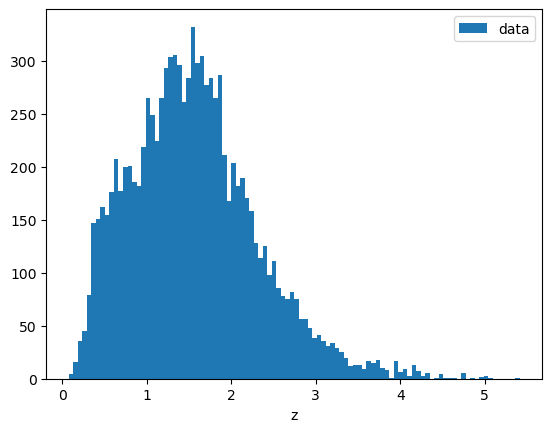

In [4]:
plt.hist(z, histtype = 'stepfilled', bins = 100, label = 'data')
plt.xlabel('z')
plt.legend()

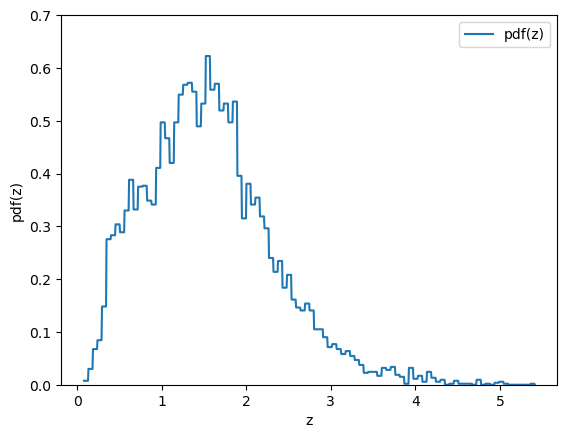

In [5]:
#Let's check out the empirical pdf we get form the data
x = np.linspace(np.min(z), np.max(z), 1000)
plt.plot(x, pdf.pdf(x), label = 'pdf(z)')
plt.ylim(0,0.7)
plt.xlabel('z')
plt.ylabel('pdf(z)')
plt.legend()

#### Rejection sampling:

In [6]:
N = 10000 #Number of samples we want to get
new_data = []

prop_pdf = stats.uniform(0, np.max(z)) #Proposal pdf to draw the samples from
uni = stats.uniform(0, np.max(pdf.pdf(z))) 

while len(new_data) < N:
    x = prop_pdf.rvs(1) #Get a value from 0 to the max of z
    u = uni.rvs(1) #And get a random value between 0 and the max of the pdf of z 
    if u <= pdf.pdf(x): #Acceptance value
        new_data.append(x)

Text(0.5, 1.0, 'Rejection sampling')

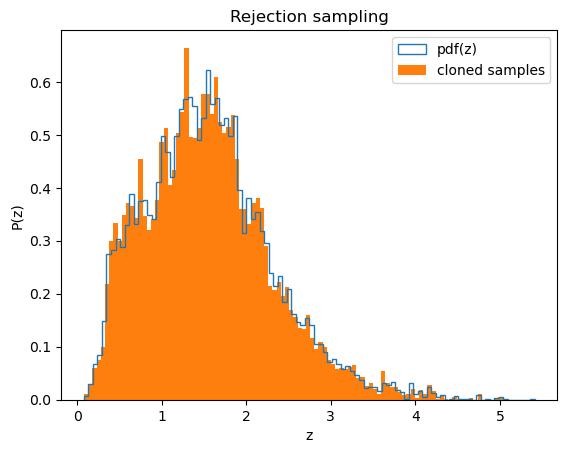

In [7]:
data = np.array(new_data)
plt.hist(z, histtype = 'step', bins = 100, density = True, label = 'pdf(z)')
plt.hist(data, bins = 100, density = True, label = 'cloned samples', histtype = 'stepfilled')
plt.xlabel('z')
plt.ylabel('P(z)')
plt.legend()
plt.title('Rejection sampling')

### Inverse transform sampling

In [8]:
N = 10000 #Number of samples we want to generate 
inv_samples = []
while len(inv_samples) < N:
    u = np.random.uniform(0,1)
    x = pdf.ppf(u)
    inv_samples.append(x)

Text(0.5, 1.0, 'Inverse transform sampling')

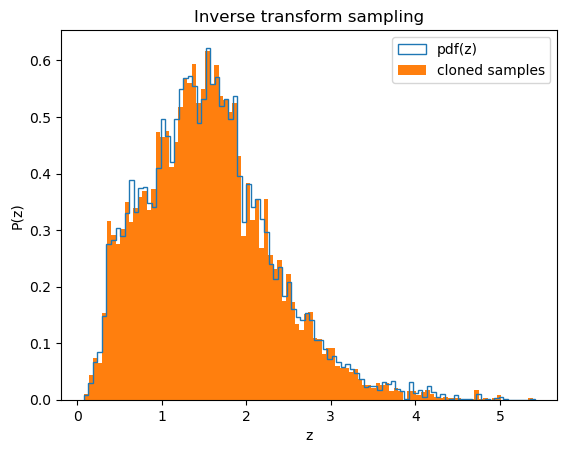

In [10]:
inv_samples = np.array(inv_samples)
plt.hist(z, histtype = 'step', bins = 100, density = True, label = 'pdf(z)')
plt.hist(inv_samples, bins = 100, density = True, label = 'cloned samples', histtype = 'stepfilled')
plt.xlabel('z')
plt.ylabel('P(z)')
plt.legend()
plt.title('Inverse transform sampling')

### Cosmology of quasars:

We expect quasars to be distributed in a uniform way in comoving volume! Let's see if this is what we have in our data:

In [11]:
import astropy
from scipy import integrate
astropy.cosmology.Planck18

FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897)

In [12]:
def pdf_nonorm(z):
    return 4.*np.pi*astropy.cosmology.Planck18.differential_comoving_volume(z).value

max_z = np.max(z)

norm_const, error = integrate.quad(pdf_nonorm, 0, max_z)
print(f"Normalization constant: {norm_const:.2e}")

def pdf_norm(z):
    return pdf_nonorm(z)/norm_const

Normalization constant: 2.27e+12


Text(0.5, 1.0, 'Theory vs Reality')

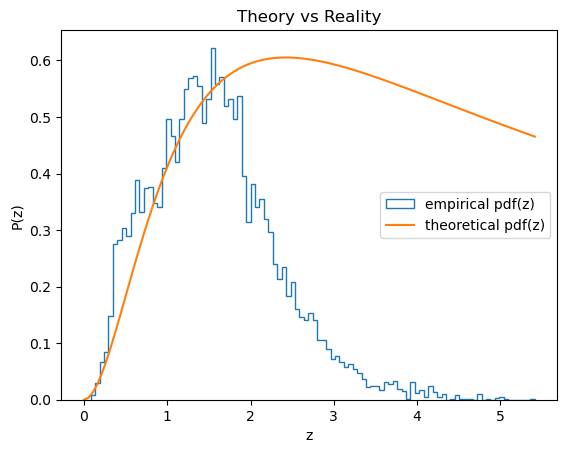

In [13]:
z_values = np.linspace(0, max_z, 100)
theoretical_pdf = pdf_norm(z_values)
plt.hist(z, histtype = 'step', bins = 100, density = True, label = 'empirical pdf(z)')
plt.plot(z_values, 2.6*theoretical_pdf, label='theoretical pdf(z)') #Adding a fudge factor to 'match' the 2 distributions
plt.xlabel('z')
plt.ylabel('P(z)')
plt.legend()
plt.title('Theory vs Reality')

The empirical distribution seems to match the expected theoretical PDF at low redshift, while at higher values of z we observe significantly fewer quasars than expected. This could be explained by a selection effect: we detect fewer objects as we move further away (increasing z).